# DATA 532 Lab 4


#### This lab will be graded based on the following rubrics:
   - **1) Code** : 
      - Accuracy: The code runs perfectly and the output is clear without being unnecessarily verbose.  
      - Quality: Code readability is exceptional and code functionality is unambiguous. For example:
         * Variable names are clear and self-documenting, an appropriate amount of whitespace is used to maximize visibility, tabs and spaces are not mixed for indentation, sufficient comments are given.
         * All functions have proper documentation (docstrings in Python). 
         * Overall, code organization and documentation is impeccable. 
         * Code repetition is minimized via the use of loops/mapping functions, functions or classes or scripts/files as needed without becoming overly complicated. 
         * Functions are short, concise, and cohesive without losing clarity; code can be easily modified. 
         * Tests are present to ensure functions work as expected. Exceptions are caught and thrown if necessary.
      - Efficiency: Code is as fast as it can reasonably be given the specifications of the problem.
  - **2) Use a systematic strategy to solve the exercises:**
      1. State the problem clearly. Identify the input & output formats.
      2. Come up with some example inputs & outputs. Try to cover all edge cases.
      3. Come up with a correct solution for the problem. 
      4. Implement the solution and test it using example inputs.        

## Graphs - 6 Marks

### Exercise 1: graphs - (3 Marks)

Please find below a code that takes in an adjacency matrix and creates graph using the NetworkX python library (https://networkx.github.io/). Please refer to it for further details to complete this question.

Build upon the code provided below to do the following:

- Enter two undirected graphs (G1 and G2) using their adjacency matrices and plot them. G1 should be a dense graph with 6 nodes and G2 should be a sparse graph with 5 nodes (0.5 marks).
- Write a code to check if the two graphs are isomorphic graphs (0.5 marks)
- Create a python program for transversing G1 using DFS algorithm. Everytime you visit a node, print the node. Use sets for keeping track of visited nodes and a stack for unvisited neighbors (2 mark)

There is an inbuilt function in NetworkX to do DFS on an entered graph (Ref: https://networkx.github.io/documentation/stable/reference/algorithms/traversal.html), you could try to implement it and print the output. 

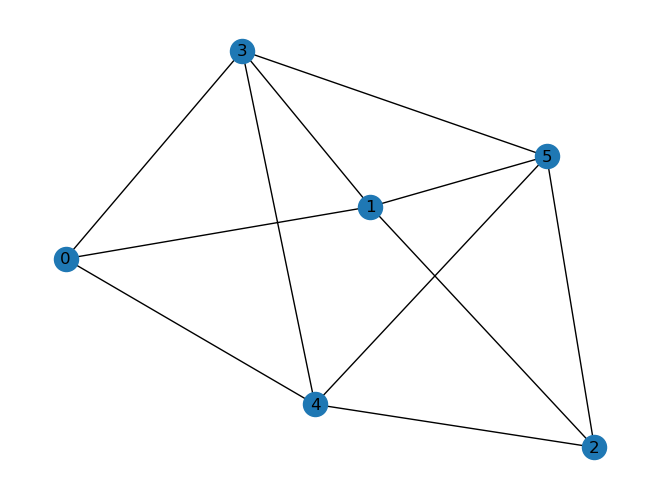

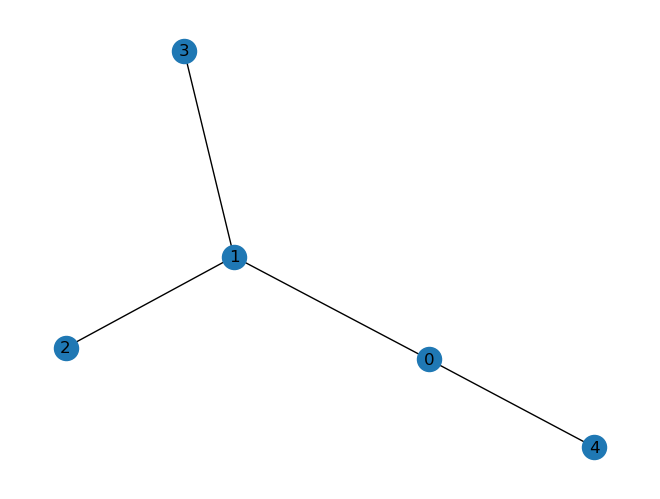

In [7]:
import matplotlib.pyplot as plt
%matplotlib inline
import networkx as nx    
import numpy as np


### Your code goes here
G1 = nx.Graph() 
adj1 = np.array([
    [0,1,0,1,1,0],
    [1,0,1,1,0,1],
    [0,1,0,0,1,1],
    [1,1,0,0,1,1],
    [1,0,1,1,0,1],
    [0,1,1,1,1,0],
]) # Complete
   
G1 = nx.from_numpy_array(adj1)


plt.figure()
nx.draw(G1, with_labels=True) # Complete
plt.show()



### Your code goes here
G2 = nx.Graph()
adj2 = np.array([
    [0,1,0,0,1],
    [1,0,1,1,0],
    [0,1,0,0,0],
    [0,1,0,0,0],
    [1,0,0,0,0],
]) # Complete

G2 = nx.from_numpy_array(adj2)

plt.figure()
nx.draw(G2, with_labels=True) # Complete
plt.show()

**Sample Output:** The exact layout will differ, but your graphs should look similar to these:

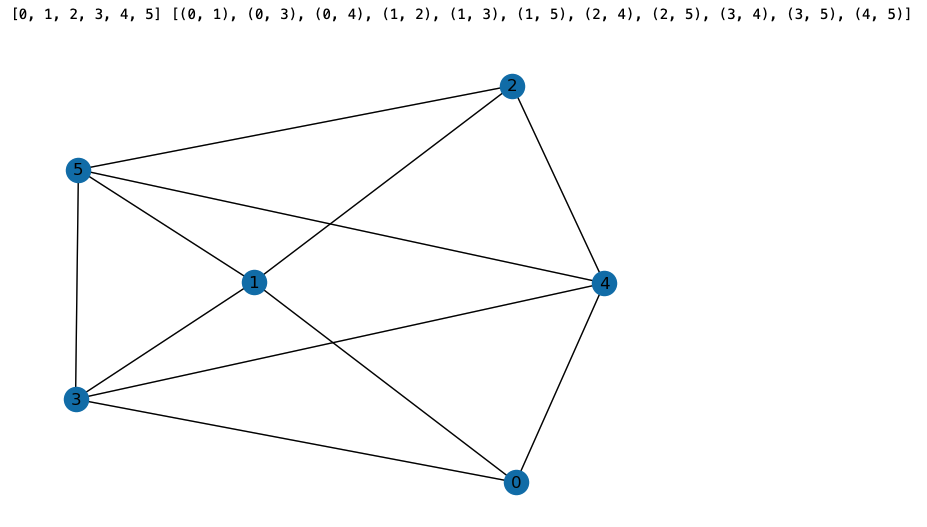

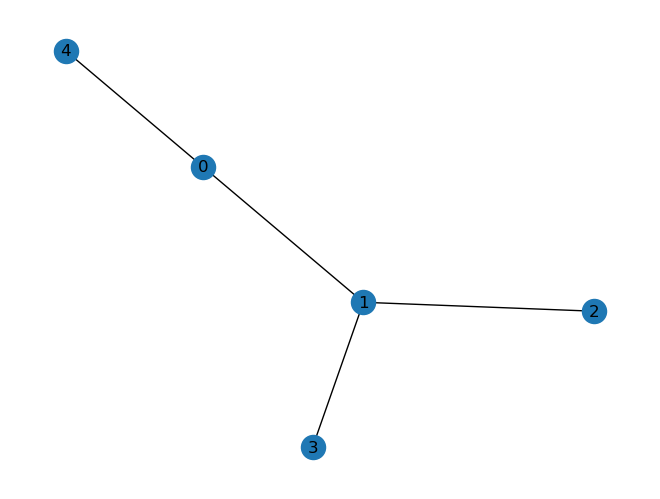

*Note: Node positions will vary each time you run the code. What matters is the structure - G1 should have 6 nodes with density > 0.5 (dense) and G2 should have 5 nodes with density < 0.5 (sparse).*

In [9]:
### Your code goes here to check if the two graphs are the same 

GM = nx.algorithms.isomorphism.GraphMatcher(G1, G2)
print(f'Testing if the two graphs the same: {GM.is_isomorphic()}')

Testing if the two graphs the same: False


In [36]:
### Your code goes here to do DFS on G1.

## your implementation goes here

visited = []
stack = [0] # start at node 0

while len(stack) > 0: # loop until the stack is empty
    
    node = stack.pop() # remove the top node from the stack and process
    
    if node not in visited: # ignore if the node is already visted

        visited.append(node)

        nextNodes = G1.neighbors(node)

        # nodes can only be added to the stack if they have not yet been visited
        validNextNodes = [] 
        for nextNode in nextNodes:
            if nextNode not in visited:
                validNextNodes.append(nextNode)
                
        stack.extend(validNextNodes)

        print(f"Visited: {node}")
        print(f"Stack: {stack}")


Visited: 0
Stack: [1, 3, 4]
Visited: 4
Stack: [1, 3, 2, 3, 5]
Visited: 5
Stack: [1, 3, 2, 3, 1, 2, 3]
Visited: 3
Stack: [1, 3, 2, 3, 1, 2, 1]
Visited: 1
Stack: [1, 3, 2, 3, 1, 2, 2]
Visited: 2
Stack: [1, 3, 2, 3, 1, 2]


**Expected Output:** Your DFS traversal should print visited nodes and the stack state. The exact order depends on your starting node and how you add neighbors to the stack, but it should visit all 6 nodes exactly once.

Example output starting from node 0:
```
Visited: 0
Stack: [1, 3, 4]
Visited: 4
Stack: [1, 3, 2, 3, 5]
Visited: 5
Stack: [1, 3, 2, 3, 1, 2, 3]
Visited: 3
Stack: [1, 3, 2, 3, 1, 2, 1]
Visited: 1
Stack: [1, 3, 2, 3, 1, 2, 2]
Visited: 2
Stack: [1, 3, 2, 3, 1, 2]
```

### Exercise 2: Social network in Romeo & Juliet - 3 Marks

![](romeo-and-juliet-undirected.png)

An edge between person A and person B means that A considers B a friend, and also B considers A a friend.

This graph is unable to represent certain information. For example, Count Paris wishes to wed Juliet, but she does not reciprocate his affection. To represent this, we would need a _directed graph_. You do not need to worry about this for this assignment; in any case; social network sites like Facebook do not represent this information either. (Some other social networking sites, such as Twitter and Google+, do permit one-way links.)

In the image above, ignore the gray background and the labels for the families ("houses"); those are there just to help you interpret the graph but are not part of the social network itself.

##### Distance

One interesting measure in a social network graph is the "distance" or number of "degrees of separation" between two people. This notion is used in academic research via the [Erdős number](https://en.wikipedia.org/wiki/Erd%C5%91s_number) and in the film industry via the [Bacon number](https://en.wikipedia.org/wiki/Six_Degrees_of_Kevin_Bacon#Bacon_numbers). For example, in the above graph, the distance between Juliet and Romeo is 1, and the distance between Juliet and Paris is 2 (via Capulet).

##### Representing a graph in Python

We will use the [NetworkX](http://networkx.github.io/) library to represent a graph in Python. 

- Create a graph named `rj` corresponding to the Romeo and Juliet graph above (ignoring the shaded family/house information). The nodes may appear in different locations; that's fine as long as the same nodes exist and they are connected in the same way by the edges. (1 Mark)

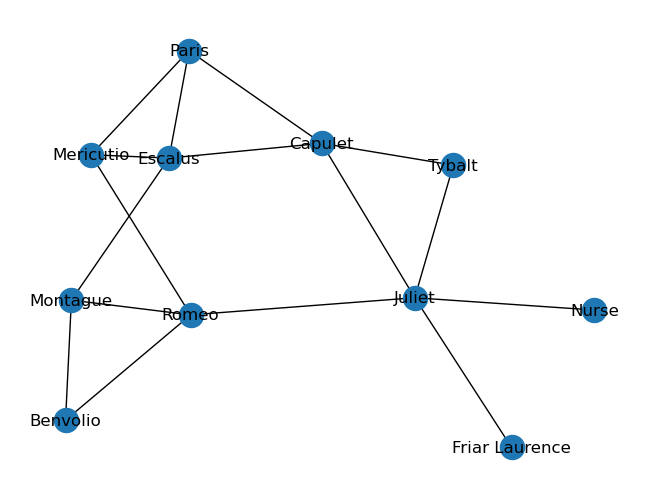

In [28]:
rj = nx.Graph() 
adjList = {
    "Friar Laurence": ["Juliet"],
    "Nurse": ["Juliet"],
    "Juliet": ["Friar Laurence", "Nurse", "Tybalt", "Capulet", "Romeo"],
    "Tybalt": ["Juliet", "Capulet"],
    "Capulet": ["Juliet", "Tybalt", "Paris", "Escalus"],
    "Paris": ["Capulet", "Escalus", "Mericutio"],
    "Mericutio": ["Paris", "Escalus"],
    "Escalus": ["Mericutio", "Capulet", "Paris", "Montague"],
    "Romeo": ["Juliet", "Mericutio", "Montague", "Benvolio"],
    "Montague": ["Romeo", "Escalus", "Benvolio"],
    "Benvolio": ["Romeo", "Montague"]
}

rj = nx.from_dict_of_lists(adjList)

plt.figure()
nx.draw(rj, with_labels=True)
plt.show()

**Sample Output:** Your graph should look similar to this (node positions will vary):

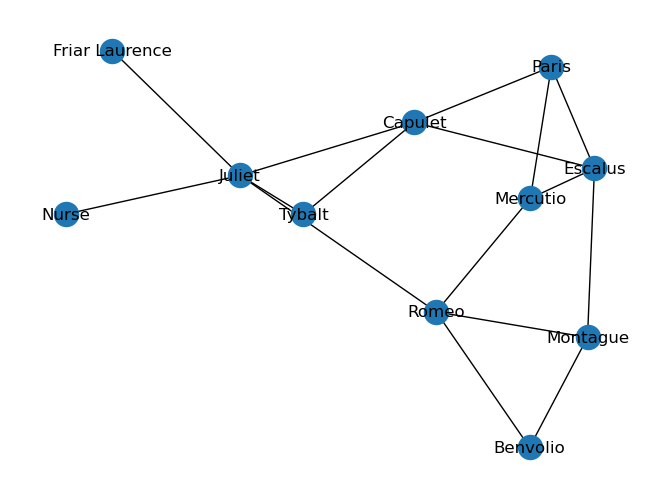

*Note: The layout will be different each time. Verify you have all 11 characters and 16 edges connecting them correctly.*

- Write a function `distance_BFS` that takes in a graph and two nodes, and uses breadth-first search (BFS) to compute the degrees of separation between the two nodes. Use Queue in the function (2 Marks)


In [50]:
def distance_BFS(g, node1, node2):
    # code goes here
        
    visited = []
    queue = [[node1, 0]] # [node, distance]
    
    while len(queue) != 0: # loop until the queue is empty

        nodeInfo = queue.pop(0) # get the front node from the queue
        currentNode = nodeInfo[0]
        distance = nodeInfo[1]
        
        if currentNode == node2: # checking if we have we found the end
            return distance
            
        elif currentNode not in visited: # checking if we have visited this node already, if so skip
            
            visited.append(currentNode)

            # nodes can only be added to the queue if they have not yet been visited
            for nextNode in g.neighbors(currentNode):
                if nextNode not in visited:
                    queue.append((nextNode, distance + 1)) # must add 1 to distance each time the end is not found

# Test your function
distance = distance_BFS(rj, "Nurse", "Paris")
print(distance)

3


**Expected Output:** `3`

**Additional test cases:**
- `distance_BFS(rj, "Juliet", "Romeo")` → `1`
- `distance_BFS(rj, "Juliet", "Paris")` → `2`
- `distance_BFS(rj, "Romeo", "Tybalt")` → `2`

# Dynamic Programming - 3 Marks

## Knapsack Problem - 3 Marks

The knapsack problem is another classic dynamic programming exercise. The generalization of this problem is very old and comes in many variations, and there are actually multiple ways to tackle this problem aside from dynamic programming.

The problem at its core is one of combinatorial optimization. Given a set of items, each with a mass and a value, determine the collection of items that results in the highest possible value while not exceeding some limit on the total weight. The variation we'll look at is commonly referred to as the 0–1 knapsack problem, which restricts the number of copies of each kind of item to 0 or 1. More formally, given a set of n items each with weight w_i and value v_i along with a maximum total weight W, our objective is:

max Σv_ix_i, where Σ w_ix_i≤W

* Either complete the code below or you can write you own function to solve the Knapsack problem using DP (2 marks)
* Add a markdown cell below to explain the intuition behind how you can solve the Knapsack problem using Dynamic Problem (1 marks)

In [68]:
import numpy as np

def knapsack(W, wt, val):  
    
    n = len(val)

    # Setting up a matrix to store the calculated values of the sub-solutions
    dp=[]
    for i in range(n+1):
        dp.append(np.zeros(W+1))

    for i in range(1, n+1): # For each available value
        for j in range(1, W+1): # For each weight up to the input weight

            if j >= wt[i-1]: # Checking if there is enough room for another item
                
                includeValue = val[i-1] + dp[i-1][j-wt[i-1]]
                excludeValue = dp[i-1][j]
                
                dp[i][j] = max(includeValue, excludeValue)
                
            else:
                dp[i][j] = dp[i-1][j]

    return int(dp[-1][-1]) # The last value is the solution to the main problem

# Testing the function Knapsack
wt = [5, 8, 1]
val = [28, 43, 82]
W = 15

knapsack(W, wt, val)

153

First, we need a 2D matrix to store the calculated values of the sub-solutions to the Knapsack problem. Each row allows a different number of included items, each column represents a different weight limit. The goal is to populate each element of the matrix with the solution to the Knapsack problem for the given weight limit and only using the specified number of items. This way, the matrix will contain the solution to the main problem, but also all sub-solutions as well. We start with the simpliest case, the top row where only 1 item is allowed. We start with a max weight of 0 in the right column and increase the max weight by one for each column up to W. When calulating the value for an element, we fetch the previous sub-solutions to help with compuation.

**Expected Output:** `153`

(All three items fit: 5+8+1=14 ≤ 15, total value: 28+43+82=153)

# Priority queue - 3 Marks

## Heap - 3 Marks

[Rock battle](https://bytes.usc.edu/cs103/labs/lab7/index.html)
Given a collection of stones, we wish to determine the last standing stone as follow. 
* Each stone has a weight (positive integer). When 2 stones s1 and s2 battle, the winning stone s is the heaviest. Its weight after the battle is computed as s.weight = |s1.weight - s2.weight|. If both stones have the same weight s1.weight=s2.weight then both stones are destroyed.
* Given a collection of stones, represented as a vector of integers, select the 2 heaviest stones, have them battle, and insert the resulting stone in the collection. Keep battling until a single stone is left. Return the weight of that stone. (If no stone is left, return 0.)

Write python code to simulate a rock battle. You do not have to write your own data structure, and can use Python built-in data structures.

In [3]:
import heapq

def last_stone_weight(stones):

    negativeStones = []
    for stone in stones:
        negativeStones.append(-stone)

    heapq.heapify(negativeStones)

    while len(negativeStones) > 1:
        
        stone1 = -heapq.heappop(negativeStones) # heaviest
        stone2 = -heapq.heappop(negativeStones) # 2nd heaviest

        if stone1 != stone2:
            heapq.heappush(negativeStones, -(stone1-stone2))

    if len(negativeStones) == 0:
        return 0
    else:
        return -negativeStones[0]

# Example usage:
stones = [2, 7, 4, 1, 8, 1]
print(last_stone_weight(stones))


1


**Expected Output:** 

Initial stones: [2, 7, 4, 1, 8, 1]

Final result: 1